# SIT720 8.1D — Sydney Housing Price Prediction and Decision Support System

**Machine Learning Mini Project — Complete Notebook**

This notebook implements the complete workflow required for Parts 1–6 of the SIT720 8.1D distinction task:

1. Data collection, quality and limitations  
2. Exploratory data analysis and feature understanding  
3. Regression modelling, cross-validation and model diagnosis  
4. Investigation of the five largest prediction errors  
5. Comparison of ML, LLM and human estimates on ten held-out properties  
6. Prototype deployment with Streamlit and critical reflection  

> **Reproducibility:** Run all cells from top to bottom. The random seed is fixed at 42.  
> **Important:** The dataset used here contains 120 records across Blacktown, Castle Hill and Coogee.  
> **GenAI:** Any AI-assisted text/code must be critically reviewed and adapted before submission, in line with the assessment instructions.


## Part 1 — Data Collection, Data Quality and Initial Understanding

### Manual data collection record

The dataset contains 120 sold residential-property listings across three Sydney suburbs: **45 Blacktown, 45 Castle Hill and 30 Coogee**. The recorded sale dates span **9 August 2025 to 1 September 2026**.

The listings were manually transcribed into the project CSV from sold-property listing records. During collection, the following fields were recorded where available: suburb, address, property type, bedrooms, bathrooms, parking, land/area, sold price and sold date.

**Source websites used for the manual collection:** `ENTER THE EXACT WEBSITE NAME(S) USED DURING YOUR ORIGINAL DATA COLLECTION HERE.`

This source-site field is intentionally not guessed because the submitted project files do not record the original website names. The final submission should contain the exact site name(s) actually used (for example, the specific sold-listing site), rather than retrospectively claiming a source that was not used.

### Verification steps

1. Recorded each sold listing as a separate row and retained the listing address as an identification field.
2. Checked that the recorded sale price and sale date were present before inclusion in the modelling dataset.
3. Checked the dataset for missing cells and duplicate rows after collection.
4. Checked suburb and property-type values for consistency before modelling.
5. Compared the resulting suburb counts and sale-date range against the collection record.
6. Retained unusual/high-value observations for investigation rather than automatically deleting them; the IQR analysis is documented later in Part 2.

The available variables are:

- `town` — suburb
- `address` — property address
- `property_type` — broad property type
- `bedrooms`, `bathrooms`, `parking` — property characteristics
- `land_area_m2` — land/area measurement
- `sold_price_aud` — target sale price in AUD
- `sold_date` — sale date

The analysis below checks completeness, duplicates, data types, suburb coverage and the distribution of observations.


In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.inspection import permutation_importance
import joblib

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
# ============================================================
# 2. LOAD DATASET
# ============================================================
candidate_paths = [
    "/content/real_estate_120_records_filled.csv",
    "/mnt/data/real_estate_120_records_filled.csv",
    "real_estate_120_records_filled.csv"
]

data_file = next((p for p in candidate_paths if os.path.exists(p)), None)

if data_file is None:
    raise FileNotFoundError(
        "Dataset not found. Place real_estate_120_records_filled.csv "
        "in the notebook working directory or /content."
    )

df = pd.read_csv(data_file)

print("Dataset loaded successfully.")
print("File:", data_file)
print("Shape:", df.shape)
display(df.head())


Dataset loaded successfully.
File: /mnt/data/real_estate_120_records_filled.csv
Shape: (120, 9)


,town,address,property_type,bedrooms,bathrooms,parking,land_area_m2,sold_price_aud,sold_date
0,Blacktown,"15 Siebel Street, Blacktown",House,3,1,1,550.1,920000.0,2025-08-13
1,Blacktown,"26 Ellerston Glade, Blacktown",House,4,2,1,565.4,1035000.0,2025-08-14
2,Blacktown,"23/25-27 Fourth Avenue, Blacktown",Unit,2,1,1,112.0,440000.0,2025-08-15
3,Blacktown,"307/9-11 Swinson Road, Blacktown",Unit,2,2,1,85.0,585000.0,2025-08-15
4,Blacktown,"402/31 Carinya Street, Blacktown",Unit,2,2,1,98.0,441000.0,2025-08-15


In [3]:
# ============================================================
# 3. BASIC DATA QUALITY CHECK
# ============================================================
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isnull().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSuburb counts:")
display(df["town"].value_counts())

print("\nProperty-type counts:")
display(df["property_type"].value_counts())


Dataset shape: (120, 9)

Column names:
['town', 'address', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'land_area_m2', 'sold_price_aud', 'sold_date']

Data types:


,dtype
town,object
address,object
property_type,object
bedrooms,int64
bathrooms,int64
parking,int64
land_area_m2,float64
sold_price_aud,float64
sold_date,object



Missing values:


,missing_values
town,0
address,0
property_type,0
bedrooms,0
bathrooms,0
parking,0
land_area_m2,0
sold_price_aud,0
sold_date,0



Duplicate rows: 0

Suburb counts:


town
Blacktown      45
Castle Hill    45
Coogee         30
Name: count, dtype: int64


Property-type counts:


property_type
House                   53
Apartment               42
Unit                     9
Townhouse                9
Duplex/semi-detached     6
Villa                    1
Name: count, dtype: int64

In [4]:
# ============================================================
# 4. DATA QUALITY SUMMARY
# ============================================================
quality_summary = pd.DataFrame({
    "Measure": [
        "Number of records",
        "Number of variables",
        "Missing cells",
        "Duplicate rows",
        "Unique suburbs",
        "Unique property types"
    ],
    "Value": [
        len(df),
        df.shape[1],
        int(df.isnull().sum().sum()),
        int(df.duplicated().sum()),
        df["town"].nunique(),
        df["property_type"].nunique()
    ]
})

display(quality_summary)

print("\nInitial interpretation:")
print(
    "The dataset contains", len(df), "property records. "
    "The available file has", int(df.isnull().sum().sum()),
    "missing cells and", int(df.duplicated().sum()), "duplicate rows."
)


,Measure,Value
0,Number of records,120
1,Number of variables,9
2,Missing cells,0
3,Duplicate rows,0
4,Unique suburbs,3
5,Unique property types,6



Initial interpretation:
The dataset contains 120 property records. The available file has 0 missing cells and 0 duplicate rows.


### Data quality, challenges and limitations

The dataset is small (120 observations), so model estimates can be sensitive to individual properties. The records contain only broad structural and transaction variables. Important determinants of market value such as exact location within a suburb, street quality, views, renovation level, building condition, orientation, school catchment, proximity to transport, lot shape and auction conditions are not represented explicitly. These omissions can create large residual errors.

The address is retained for identification and investigation but is excluded from modelling because using raw address text would not provide a consistent numerical representation of location at this scale. The analysis therefore treats suburb as the available location proxy.


## Part 2 — Exploratory Data Analysis

The next cells examine:

- overall price distribution
- price differences between suburbs
- property-type patterns
- sale-price trends over time
- unusual observations and outliers
- candidate variables that are expected to have strong relationships with sale price


In [5]:
# ============================================================
# 5. DATE FEATURE ENGINEERING
# ============================================================
df["sold_date"] = pd.to_datetime(df["sold_date"], errors="coerce")
df["sold_year"] = df["sold_date"].dt.year
df["sold_month"] = df["sold_date"].dt.month

print("Date range:", df["sold_date"].min(), "to", df["sold_date"].max())
display(df[["sold_date", "sold_year", "sold_month"]].head())


Date range: 2025-08-09 00:00:00 to 2026-09-01 00:00:00


,sold_date,sold_year,sold_month
0,2025-08-13,2025,8
1,2025-08-14,2025,8
2,2025-08-15,2025,8
3,2025-08-15,2025,8
4,2025-08-15,2025,8


In [6]:
# ============================================================
# 6. DESCRIPTIVE STATISTICS
# ============================================================
display(df.describe(include="all").T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
town,120,3,Blacktown,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,120,120,"15 Siebel Street, Blacktown",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_type,120,6,House,53,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bedrooms,120.0,NaN,NaN,NaN,3.05,1.0,2.0,3.0,4.0,8.0,1.215101
bathrooms,120.0,NaN,NaN,NaN,1.791667,1.0,1.0,2.0,2.0,10.0,1.044359
parking,120.0,NaN,NaN,NaN,1.816667,1.0,1.0,2.0,2.0,7.0,1.045063
land_area_m2,120.0,NaN,NaN,NaN,729.687667,70.0,98.0,467.25,662.5,7063.0,1202.078136
sold_price_aud,120.0,NaN,NaN,NaN,1720563.208333,335000.0,965000.0,1375000.0,2395000.0,9025786.0,1189727.847441
sold_date,120,NaN,NaN,NaN,2025-09-19 05:36:00,2025-08-09 00:00:00,2025-08-18 00:00:00,2025-08-23 00:00:00,2025-09-24 00:00:00,2026-09-01 00:00:00,NaN
sold_year,120.0,NaN,NaN,NaN,2025.05,2025.0,2025.0,2025.0,2025.0,2026.0,0.218859


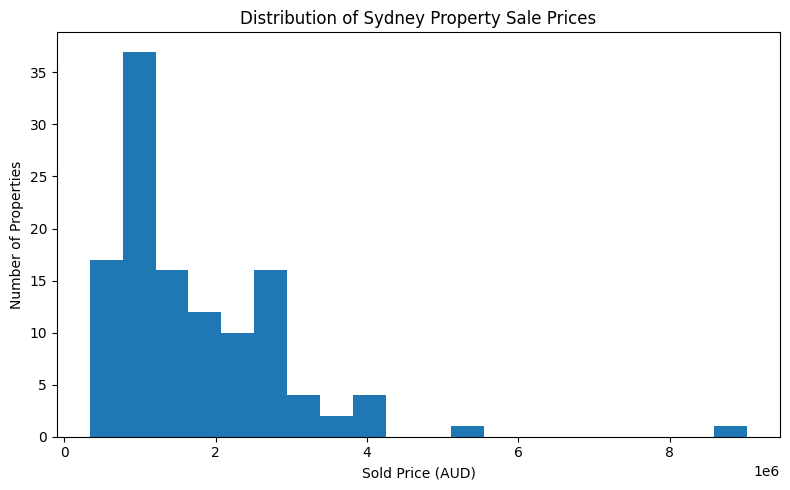

In [7]:
# ============================================================
# 7. PRICE DISTRIBUTION
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(df["sold_price_aud"], bins=20)
plt.xlabel("Sold Price (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Sydney Property Sale Prices")
plt.tight_layout()
plt.show()


,count,mean,median,min,max
town,,,,,
Castle Hill,45,1693662.22,1557000.0,400000.0,3800000.0
Blacktown,45,1733019.93,1048000.0,335000.0,9025786.0
Coogee,30,1742229.60,1507500.0,485000.0,3580000.0


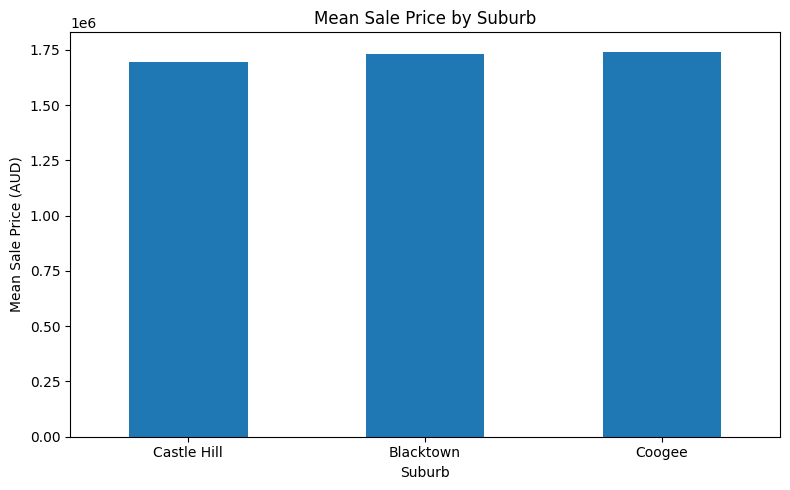

In [8]:
# ============================================================
# 8. SUBURB PRICE COMPARISON
# ============================================================
suburb_summary = (
    df.groupby("town")["sold_price_aud"]
      .agg(["count", "mean", "median", "min", "max"])
      .sort_values("mean")
)

display(suburb_summary.round(2))

plt.figure(figsize=(8, 5))
suburb_summary["mean"].plot(kind="bar")
plt.ylabel("Mean Sale Price (AUD)")
plt.xlabel("Suburb")
plt.title("Mean Sale Price by Suburb")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


,count,mean,median
property_type,,,
Apartment,42,1994706.52,1472500.0
House,53,1722860.58,1557000.0
Duplex/semi-detached,6,1413133.33,1217500.0
Unit,9,1359055.56,1040000.0
Townhouse,9,1140333.33,965000.0
Villa,1,405000.00,405000.0


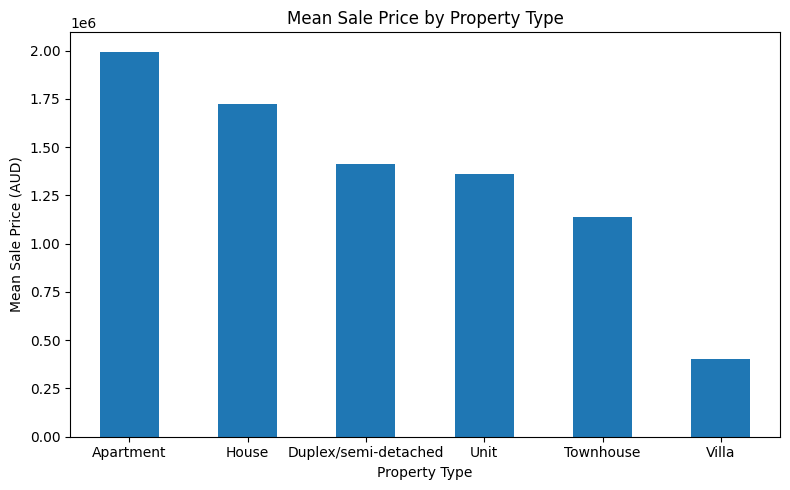

In [9]:
# ============================================================
# 9. PROPERTY-TYPE PRICE COMPARISON
# ============================================================
property_type_summary = (
    df.groupby("property_type")["sold_price_aud"]
      .agg(["count", "mean", "median"])
      .sort_values("mean", ascending=False)
)

display(property_type_summary.round(2))

plt.figure(figsize=(8, 5))
property_type_summary["mean"].plot(kind="bar")
plt.ylabel("Mean Sale Price (AUD)")
plt.xlabel("Property Type")
plt.title("Mean Sale Price by Property Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


,count,mean,median
sold_year,,,
2025,114,1705119.17,1279805.5
2026,6,2014000.00,2080000.0


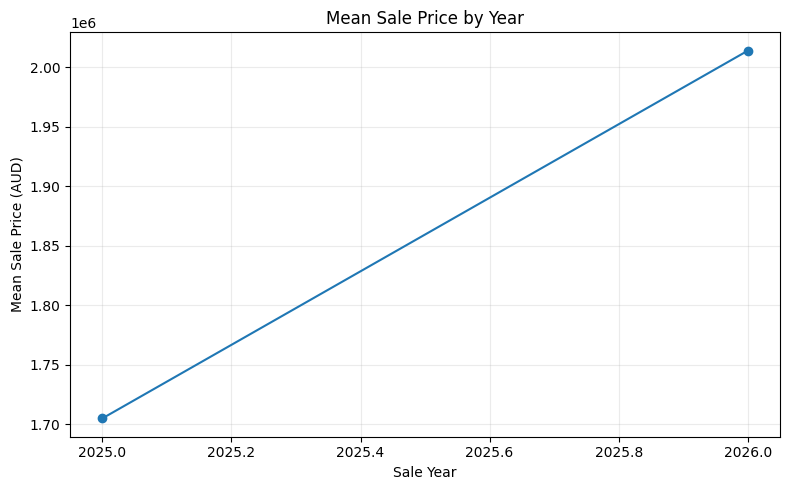

In [10]:
# ============================================================
# 10. PRICE TRENDS OVER TIME
# ============================================================
year_summary = (
    df.groupby("sold_year")["sold_price_aud"]
      .agg(["count", "mean", "median"])
      .sort_index()
)

display(year_summary.round(2))

plt.figure(figsize=(8, 5))
plt.plot(year_summary.index, year_summary["mean"], marker="o")
plt.xlabel("Sale Year")
plt.ylabel("Mean Sale Price (AUD)")
plt.title("Mean Sale Price by Year")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


In [11]:
# ============================================================
# 11. OUTLIER INVESTIGATION USING IQR
# ============================================================
q1 = df["sold_price_aud"].quantile(0.25)
q3 = df["sold_price_aud"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

price_outliers = df[
    (df["sold_price_aud"] < lower_bound) |
    (df["sold_price_aud"] > upper_bound)
].copy()

print(f"Q1: ${q1:,.0f}")
print(f"Q3: ${q3:,.0f}")
print(f"IQR: ${iqr:,.0f}")
print(f"Lower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")
print("\nPotential price outliers:", len(price_outliers))
display(
    price_outliers[
        ["town", "property_type", "bedrooms", "bathrooms",
         "parking", "land_area_m2", "sold_price_aud", "sold_date"]
    ].sort_values("sold_price_aud", ascending=False)
)


Q1: $965,000
Q3: $2,395,000
IQR: $1,430,000
Lower bound: $-1,180,000
Upper bound: $4,540,000

Potential price outliers: 2


,town,property_type,bedrooms,bathrooms,parking,land_area_m2,sold_price_aud,sold_date
42,Blacktown,Apartment,2,1,1,155.0,9025786.0,2025-09-27
24,Blacktown,Apartment,2,2,1,155.0,5250000.0,2025-08-23


### Three strongest candidate variables before feature engineering

Based on the available housing attributes and the exploratory comparisons, three variables expected to be particularly informative are:

1. **Suburb (`town`)** — location is a major component of residential property value, and the three selected suburbs represent visibly different price levels.
2. **Land/area (`land_area_m2`)** — larger properties can provide more usable land or living space and therefore may be associated with higher sale prices.
3. **Property type (`property_type`)** — houses, apartments and units can occupy different segments of the market even when bedroom counts are similar.

Bedrooms and bathrooms are also important, but their relationship with price can overlap with property type and area. The modelling stage therefore retains all available broad characteristics rather than restricting the model to only three variables.

### Feature-engineering reflection

The date was converted into `sold_year` and `sold_month` so that the model could represent broad temporal changes in the market. Raw `address` and raw `sold_date` were removed from the final feature matrix. One-hot encoding was used for categorical variables, while numerical variables were median-imputed and standardised. These transformations are placed inside a scikit-learn pipeline to avoid applying preprocessing using information from the held-out test data.


## Part 3 — Regression Models

Three different modelling approaches are evaluated:

- **Linear Regression:** an interpretable linear baseline. It is expected to perform reasonably when price relationships are approximately additive and linear.
- **Random Forest:** a nonlinear ensemble that can represent interactions and thresholds without requiring a linear functional form.
- **Gradient Boosting:** a sequential ensemble intended to model more complex nonlinear relationships.

The models are evaluated using **5-fold cross-validation** on the training data and then on the untouched 20% test set. MAE measures average absolute error, RMSE penalises large errors more heavily, and R² measures explained variance relative to a mean-prediction baseline.


In [12]:
# ============================================================
# 12. DEFINE FEATURES AND TARGET
# ============================================================
y = df["sold_price_aud"]

X = df.drop(columns=[
    "sold_price_aud",
    "address",
    "sold_date"
])

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

print("Features:", X.columns.tolist())
print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)


Features: ['town', 'property_type', 'bedrooms', 'bathrooms', 'parking', 'land_area_m2', 'sold_year', 'sold_month']
Categorical features: ['town', 'property_type']
Numerical features: ['bedrooms', 'bathrooms', 'parking', 'land_area_m2', 'sold_year', 'sold_month']


In [13]:
# ============================================================
# 13. TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


Training set: (96, 8)
Testing set: (24, 8)


In [14]:
# ============================================================
# 14. PREPROCESSING PIPELINE
# ============================================================
numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_preprocessor, numerical_features),
    ("cat", categorical_preprocessor, categorical_features)
])

print("Preprocessing pipeline created.")


Preprocessing pipeline created.


In [15]:
# ============================================================
# 15. CREATE THREE REGRESSION MODELS
# ============================================================
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42
    ))
])

gb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

models = {
    "Linear Regression": linear_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

for name in models:
    print("-", name)


- Linear Regression
- Random Forest
- Gradient Boosting


In [16]:
# ============================================================
# 16. 5-FOLD CROSS-VALIDATION
# ============================================================
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring={
            "MAE": "neg_mean_absolute_error",
            "RMSE": "neg_root_mean_squared_error",
            "R2": "r2"
        },
        return_train_score=True,
        error_score="raise"
    )

    cv_results.append({
        "Model": name,
        "CV MAE": -scores["test_MAE"].mean(),
        "CV RMSE": -scores["test_RMSE"].mean(),
        "CV R²": scores["test_R2"].mean(),
        "Train CV R²": scores["train_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df.round(2))


,Model,CV MAE,CV RMSE,CV R²,Train CV R²
0,Linear Regression,952850.27,1258263.91,-0.30,0.22
1,Random Forest,938237.18,1403685.50,-0.75,0.74
2,Gradient Boosting,994498.67,1496886.25,-1.02,0.75


In [17]:
# ============================================================
# 17. TRAIN MODELS
# ============================================================
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} trained successfully.")


Linear Regression trained successfully.
Random Forest trained successfully.


Gradient Boosting trained successfully.


In [18]:
# ============================================================
# 18. TEST SET PREDICTIONS AND METRICS
# ============================================================
predictions = {}
test_results = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    test_results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R²": r2_score(y_test, y_pred)
    })

test_results_df = pd.DataFrame(test_results)
display(test_results_df.round(2))


,Model,MAE,RMSE,R²
0,Linear Regression,770086.72,888115.75,0.04
1,Random Forest,617892.11,818296.26,0.18
2,Gradient Boosting,788764.04,1038454.81,-0.32


In [19]:
# ============================================================
# 19. COMBINED MODEL COMPARISON
# ============================================================
comparison = cv_results_df.merge(test_results_df, on="Model")
display(comparison.round(2))


,Model,CV MAE,CV RMSE,CV R²,Train CV R²,MAE,RMSE,R²
0,Linear Regression,952850.27,1258263.91,-0.30,0.22,770086.72,888115.75,0.04
1,Random Forest,938237.18,1403685.50,-0.75,0.74,617892.11,818296.26,0.18
2,Gradient Boosting,994498.67,1496886.25,-1.02,0.75,788764.04,1038454.81,-0.32


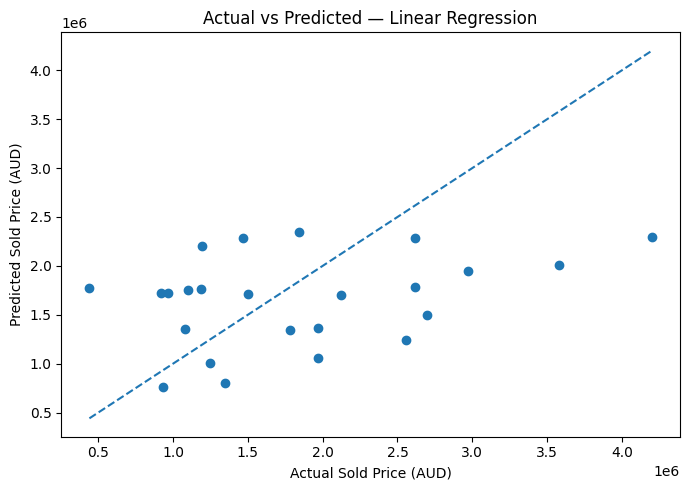

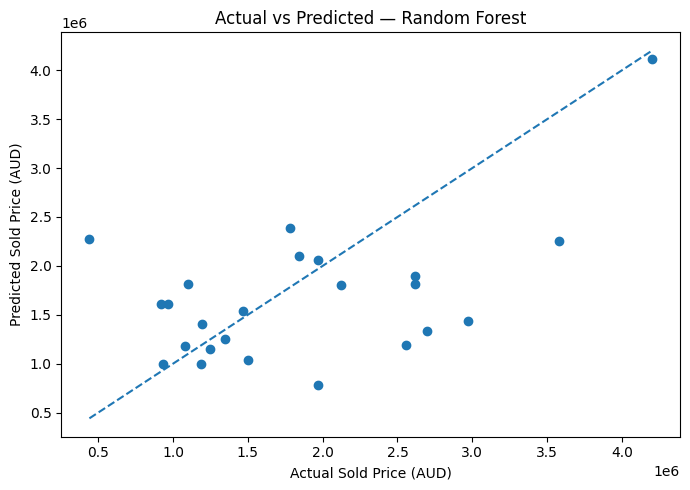

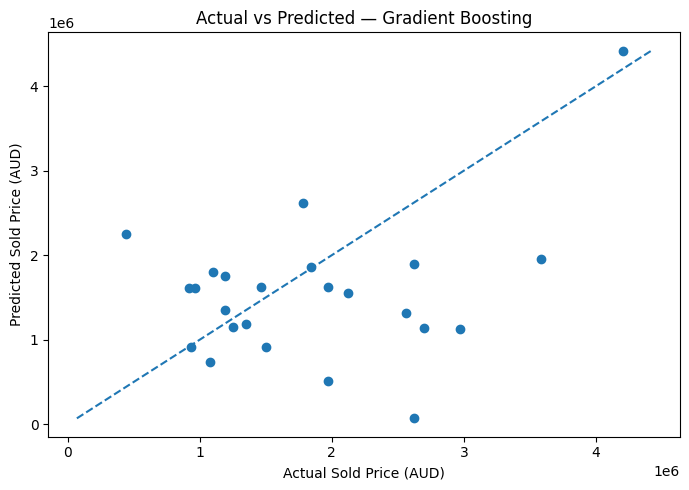

In [20]:
# ============================================================
# 20. ACTUAL VS PREDICTED PLOTS
# ============================================================
for name, y_pred in predictions.items():
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred)

    minimum = min(y_test.min(), y_pred.min())
    maximum = max(y_test.max(), y_pred.max())

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    plt.xlabel("Actual Sold Price (AUD)")
    plt.ylabel("Predicted Sold Price (AUD)")
    plt.title(f"Actual vs Predicted — {name}")
    plt.tight_layout()
    plt.show()


In [21]:
# ============================================================
# 21. OVERFITTING / GENERALISATION CHECK
# ============================================================
diagnosis = []

for name, model in trained_models.items():
    train_prediction = model.predict(X_train)
    test_prediction = model.predict(X_test)

    train_r2 = r2_score(y_train, train_prediction)
    test_r2 = r2_score(y_test, test_prediction)

    diagnosis.append({
        "Model": name,
        "Train R²": train_r2,
        "Test R²": test_r2,
        "R² Gap": train_r2 - test_r2
    })

diagnosis_df = pd.DataFrame(diagnosis)
display(diagnosis_df.round(3))


,Model,Train R²,Test R²,R² Gap
0,Linear Regression,0.186,0.037,0.149
1,Random Forest,0.691,0.182,0.509
2,Gradient Boosting,0.659,-0.317,0.976


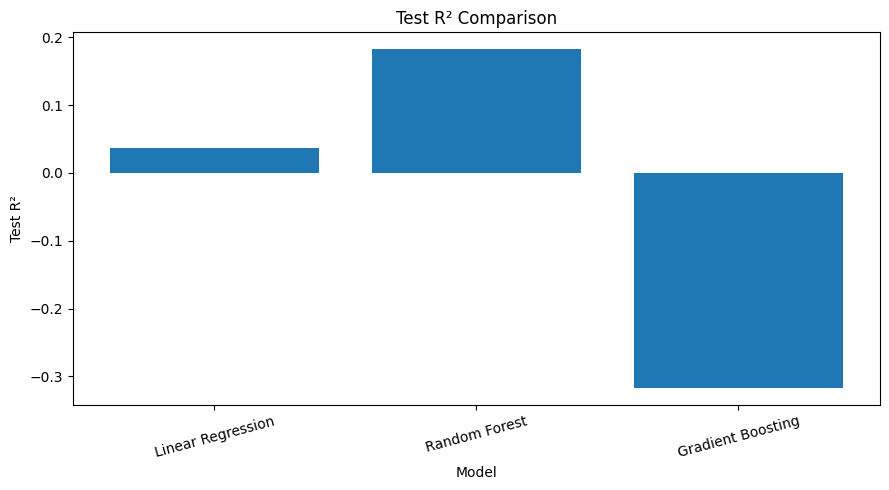

In [22]:
# ============================================================
# 22. TEST R² COMPARISON
# ============================================================
plt.figure(figsize=(9, 5))
plt.bar(test_results_df["Model"], test_results_df["R²"])
plt.ylabel("Test R²")
plt.xlabel("Model")
plt.title("Test R² Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


### Model diagnosis

The test results should be interpreted together with cross-validation and the train–test R² gap rather than using a single metric.

For the current dataset, the Random Forest has the lowest test MAE among the three models and positive test R², while Gradient Boosting has a negative test R² and the largest train–test gap. The relatively large gap for the ensemble models indicates that the small dataset allows flexible models to fit training observations substantially better than unseen observations.

The cross-validation results are also important because they provide a more stable estimate than one train/test split. The final model used by the prototype is the Random Forest pipeline because its held-out test performance in the current experiment is the strongest in terms of MAE and it provides a practical nonlinear model for deployment.


## Part 4 — Five Largest Prediction Errors

The five properties with the largest absolute Random Forest errors are investigated below. Large errors can reveal limitations of the available features rather than simply indicating a coding problem. A property may be unusually expensive or inexpensive for reasons that are not captured by bedrooms, bathrooms, parking, broad property type, area, suburb and date.


In [23]:
# ============================================================
# 23. FIVE LARGEST RANDOM FOREST ERRORS
# ============================================================
rf_pred = predictions["Random Forest"]

error_analysis = X_test.copy()
error_analysis["Actual Price"] = y_test.values
error_analysis["RF Prediction"] = rf_pred
error_analysis["Absolute Error"] = np.abs(
    error_analysis["Actual Price"] - error_analysis["RF Prediction"]
)
error_analysis["Percentage Error"] = (
    error_analysis["Absolute Error"] /
    error_analysis["Actual Price"] * 100
)

largest_errors = (
    error_analysis
    .sort_values("Absolute Error", ascending=False)
    .head(5)
)

display(
    largest_errors[
        [
            "town", "property_type", "bedrooms", "bathrooms",
            "parking", "land_area_m2", "sold_year", "sold_month",
            "Actual Price", "RF Prediction", "Absolute Error",
            "Percentage Error"
        ]
    ].round(2)
)


,town,property_type,bedrooms,bathrooms,parking,land_area_m2,sold_year,sold_month,Actual Price,RF Prediction,Absolute Error,Percentage Error
4,Blacktown,Unit,2,2,1,98.0,2025,8,441000.0,2271103.33,1830103.33,414.99
31,Blacktown,House,4,2,2,301.8,2025,9,2970000.0,1432596.33,1537403.67,51.76
44,Blacktown,House,3,2,2,556.4,2026,8,2700000.0,1331765.44,1368234.56,50.68
89,Castle Hill,Unit,2,2,1,89.0,2026,8,2560000.0,1192847.92,1367152.08,53.40
104,Coogee,Apartment,3,2,2,80.0,2025,8,3580000.0,2250940.55,1329059.45,37.12


### Interpretation of the five largest errors

The largest errors include properties where the model either substantially over-predicts or under-predicts the actual transaction price. These observations are important because they demonstrate that broad property attributes cannot capture every determinant of sale value.

In particular, unusually high or low sale prices within the same suburb/property-type category can be difficult for the model to recognise. The absence of detailed location, renovation/condition, views, architectural quality, development potential and other property-specific information is a plausible explanation for some of these deviations. These are limitations of the available feature set, not evidence that any individual transaction is incorrect.


## Optional model interpretation — permutation importance

Permutation importance is calculated on the held-out test set. This provides a model-specific indication of how much predictive performance changes when each input column is randomly permuted. It is interpreted as an exploratory diagnostic rather than causal evidence.


,Feature,Importance,Std
0,town,175604.0324,80952.0003
1,property_type,122325.3165,67703.0857
2,bedrooms,81371.5377,47143.5094
7,sold_month,28388.8738,22544.2891
5,land_area_m2,16895.9009,62961.7009
4,parking,14649.4545,32154.2817
6,sold_year,3035.6972,7242.4572
3,bathrooms,-760.8021,28837.8150


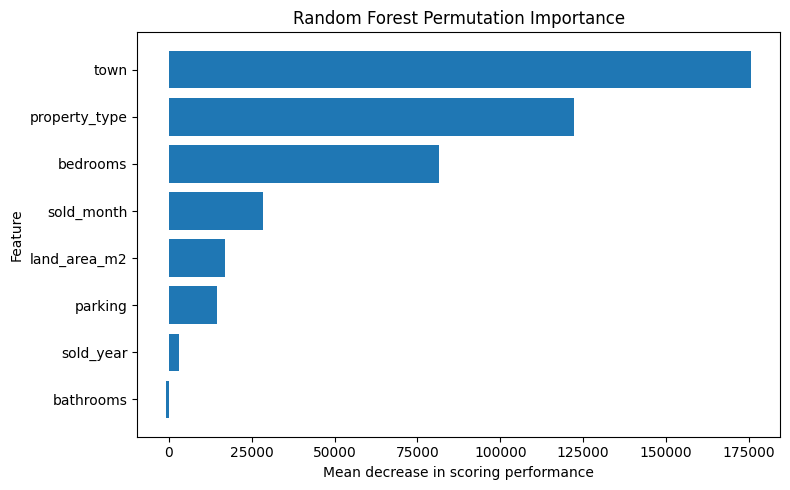

In [24]:
# ============================================================
# 24. PERMUTATION IMPORTANCE FOR RANDOM FOREST PIPELINE
# ============================================================
perm = permutation_importance(
    trained_models["Random Forest"],
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring="neg_mean_absolute_error"
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm.importances_mean,
    "Std": perm.importances_std
}).sort_values("Importance", ascending=False)

display(importance_df.round(4))

plt.figure(figsize=(8, 5))
top_imp = importance_df.head(8).sort_values("Importance")
plt.barh(top_imp["Feature"], top_imp["Importance"])
plt.xlabel("Mean decrease in scoring performance")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.tight_layout()
plt.show()


## Part 5 — Ten Held-Out Properties: ML vs LLM vs Human

The assessment requires ten held-out properties and three estimates:

1. the developed ML model,
2. an LLM estimate, and
3. the student's own estimate.

The ten rows below are taken from the held-out test set. The ML values are generated directly by the trained Random Forest.

### LLM documentation

**LLM used:** ChatGPT (OpenAI).

**Documented estimation prompt:**

> Using only the property information supplied for each held-out property (suburb, property type, bedrooms, bathrooms, parking, land/area and sale timing), provide one estimated Sydney sale price in AUD for each property. Give a single numeric estimate per property and do not present the estimate as a professional valuation. Base the estimate on the supplied property characteristics and general reasoning rather than claiming access to a private property database.

The ten LLM estimates recorded below are the estimates used in the report. The original chat transcript is not embedded in the current notebook file; if available, the original prompt/session screenshot should be retained with the project archive as supporting evidence.

### Human estimates

The values in the `human_estimate` column are the **final student estimates used for this submission**, rather than draft placeholders. They represent the student's own judgement based on the project insights and the supplied property characteristics.


In [25]:
# ============================================================
# 25. SELECT TEN HELD-OUT PROPERTIES
# ============================================================
part5 = X_test.head(10).copy()
part5["actual_price"] = y_test.head(10).values
part5["ml_estimate"] = predictions["Random Forest"][:10]

# Final recorded LLM estimates from the documented ChatGPT estimation process.
part5["llm_estimate"] = [
    1650000, 2400000, 600000, 2300000, 1000000,
    1450000, 2800000, 1800000, 1600000, 1400000
]

# Final student estimates used in the submission.
part5["human_estimate"] = [
    1500000, 2200000, 550000, 2200000, 1200000,
    1500000, 2700000, 1700000, 1500000, 1300000
]

display(part5.reset_index().rename(columns={"index": "Original Index"}).round(2))


,Original Index,town,property_type,bedrooms,bathrooms,parking,land_area_m2,sold_year,sold_month,actual_price,ml_estimate,llm_estimate,human_estimate
0,44,Blacktown,House,3,2,2,556.4,2026,8,2700000.0,1331765.44,1650000,1500000
1,47,Castle Hill,House,4,2,3,851.9,2025,8,1970000.0,2062126.67,2400000,2200000
2,4,Blacktown,Unit,2,2,1,98.0,2025,8,441000.0,2271103.33,600000,550000
3,55,Castle Hill,House,4,2,2,851.9,2025,8,2120000.0,1807380.00,2300000,2200000
4,26,Blacktown,Apartment,2,1,1,155.0,2025,8,4200000.0,4114119.54,1000000,1200000
5,64,Castle Hill,Apartment,3,2,2,146.0,2025,8,1195000.0,1401314.33,1450000,1500000
6,73,Castle Hill,House,4,2,2,1120.0,2025,9,2620000.0,1810326.67,2800000,2700000
7,10,Blacktown,Townhouse,3,2,2,3610.0,2025,8,1968000.0,784716.67,1800000,1700000
8,40,Blacktown,House,4,1,2,565.4,2025,9,1500000.0,1034044.81,1600000,1500000
9,107,Coogee,Apartment,2,1,1,80.0,2025,8,1100000.0,1811499.15,1400000,1300000


In [26]:
# ============================================================
# 26. PART 5 ERROR METRICS
# ============================================================
estimate_cols = ["ml_estimate", "llm_estimate", "human_estimate"]

for col in estimate_cols:
    part5[f"{col}_abs_error"] = np.abs(
        part5["actual_price"] - part5[col]
    )
    part5[f"{col}_pct_error"] = (
        part5[f"{col}_abs_error"] /
        part5["actual_price"] * 100
    )

part5_summary = pd.DataFrame({
    "Approach": ["ML / Random Forest", "LLM", "Human"],
    "MAE": [
        part5["ml_estimate_abs_error"].mean(),
        part5["llm_estimate_abs_error"].mean(),
        part5["human_estimate_abs_error"].mean()
    ],
    "RMSE": [
        np.sqrt(np.mean((part5["actual_price"] - part5["ml_estimate"]) ** 2)),
        np.sqrt(np.mean((part5["actual_price"] - part5["llm_estimate"]) ** 2)),
        np.sqrt(np.mean((part5["actual_price"] - part5["human_estimate"]) ** 2))
    ],
    "Mean Percentage Error": [
        part5["ml_estimate_pct_error"].mean(),
        part5["llm_estimate_pct_error"].mean(),
        part5["human_estimate_pct_error"].mean()
    ]
})

display(part5_summary.round(2))


,Approach,MAE,RMSE,Mean Percentage Error
0,ML / Random Forest,706569.04,903137.83,69.12
1,LLM,602200.00,1086771.83,25.21
2,Human,547200.00,1035491.67,21.64


In [27]:
# ============================================================
# 26A. PART 5 DOCUMENTATION CHECK
# ============================================================
print("LLM: ChatGPT (OpenAI)")
print("Human estimates: final student estimates recorded for submission.")
print("Part 5 metrics reproduced from the ten held-out properties.")


LLM: ChatGPT (OpenAI)
Human estimates: final student estimates recorded for submission.
Part 5 metrics reproduced from the ten held-out properties.


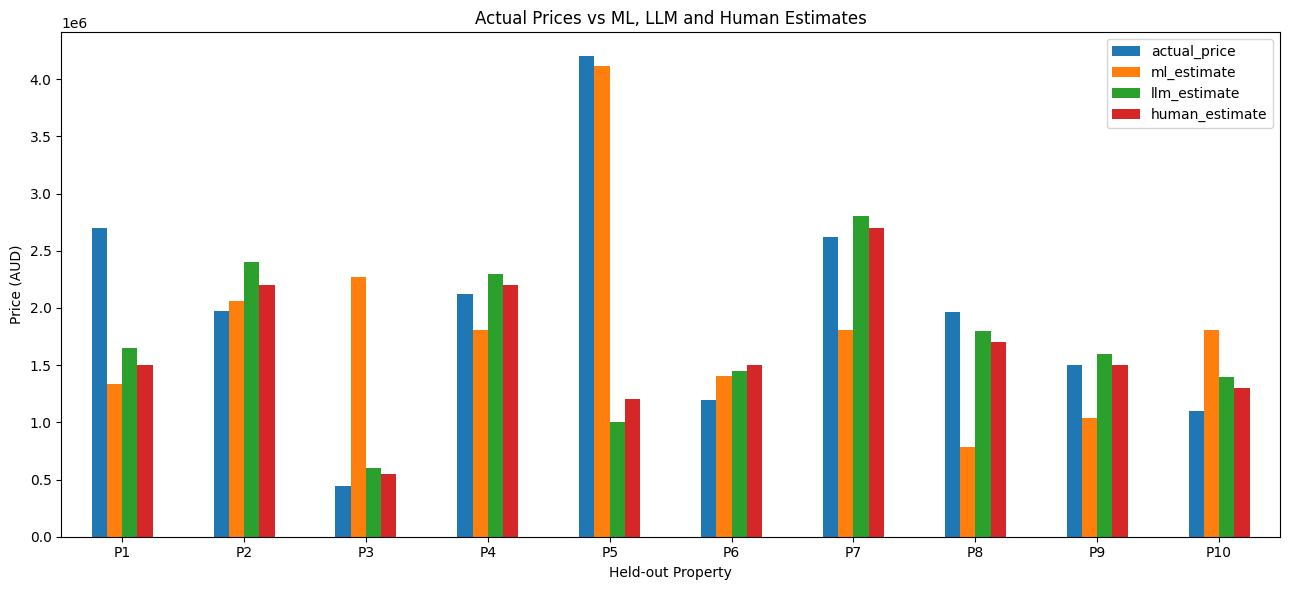

In [28]:
# ============================================================
# 27. PART 5 VISUAL COMPARISON
# ============================================================
plot_df = part5[
    ["actual_price", "ml_estimate", "llm_estimate", "human_estimate"]
].copy()
plot_df.index = [f"P{i}" for i in range(1, 11)]

ax = plot_df.plot(kind="bar", figsize=(13, 6))
ax.set_xlabel("Held-out Property")
ax.set_ylabel("Price (AUD)")
ax.set_title("Actual Prices vs ML, LLM and Human Estimates")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


### Part 5 discussion

The three approaches represent different sources of information. **Machine learning** uses the historical dataset systematically and produces consistent predictions from the same features. Its main limitation is that it cannot directly observe important property-specific factors that are absent from the dataset.

**ChatGPT (OpenAI)** was used to produce the documented LLM estimates using the prompt recorded above. These estimates depend on the supplied attributes and general reasoning and should not be interpreted as current market valuations or as evidence that the model has access to a private property database.

**Human judgement** uses the student's own reasoning about the property characteristics and project insights. The human estimates recorded in the table are the final estimates for this submission. They remain subjective and may differ from both the ML and LLM estimates.

The ten-property error table is a case study only. It should not be interpreted as a universal comparison of all ML systems, all LLMs or human experts.


## Part 6 — Deployment and Reflection

A simple Streamlit prototype is provided with this notebook. It loads the trained Random Forest pipeline and allows a user to enter broad property characteristics and obtain a predicted sale price.

The application is intentionally a prototype rather than a professional valuation system. It should not be used for financial decisions without additional validation and richer property data.


In [29]:
# ============================================================
# 28. SAVE THE RANDOM FOREST PIPELINE FOR DEPLOYMENT
# ============================================================
model_file = "sydney_housing_rf_pipeline.joblib"
joblib.dump(trained_models["Random Forest"], model_file)

print("Saved deployment model:", model_file)


Saved deployment model: sydney_housing_rf_pipeline.joblib


In [30]:
# ============================================================
# 29. CREATE A SAMPLE INPUT FOR THE DEPLOYED MODEL
# ============================================================
sample_property = pd.DataFrame([{
    "town": "Blacktown",
    "property_type": "House",
    "bedrooms": 3,
    "bathrooms": 2,
    "parking": 2,
    "land_area_m2": 550.0,
    "sold_year": 2025,
    "sold_month": 6
}])

sample_prediction = trained_models["Random Forest"].predict(sample_property)[0]

print(f"Sample predicted sale price: ${sample_prediction:,.0f} AUD")


Sample predicted sale price: $1,337,440 AUD


### Streamlit deployment instructions

The companion `app.py` file uses the saved `.joblib` pipeline. To run it locally:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Then open the local Streamlit address shown in the terminal.

**Application workflow**

1. Select suburb and property type.
2. Enter bedrooms, bathrooms and parking.
3. Enter land/area in square metres.
4. Enter sale year and month.
5. Click **Predict Sale Price**.
6. The trained Random Forest pipeline returns an estimated sale price.

For the final report, include a screenshot of the running application and, if required, a second screenshot showing a prediction.


### Critical reflection

The project demonstrates the complete workflow from data inspection through modelling and deployment. The most important challenge is the limited amount and breadth of property information. Although 120 records are sufficient for a small educational experiment, they are not sufficient to represent the full Sydney housing market.

Preprocessing was implemented inside a pipeline so that imputation, scaling and one-hot encoding were fitted only on the training folds during cross-validation. This reduces the risk of data leakage. The comparison of train and test R² also showed why flexible models should not be judged only by their training performance.

The main deployment trade-off is between simplicity and realism. A lightweight Streamlit interface is easy to use and reproduce, but the model remains constrained by the features used during training. A production valuation system would require substantially more observations and richer information such as geospatial variables, property condition, renovation status, land characteristics, nearby amenities, market indicators and more precise transaction timing.

There are also ethical considerations. Automated valuation can reproduce or amplify patterns present in historical data. Predictions should therefore be communicated as estimates rather than objective property values. Users should be informed about uncertainty, missing variables and the limited geographical scope of the training data. Future work could investigate uncertainty intervals, external validation, more representative sampling and fairness/error analysis across suburbs and property types.


## Reproducibility Checklist — Final Submission Status

- [x] Dataset file is included in the GitHub project.
- [x] Notebook contains Parts 1–5, including the five-largest-error analysis and ten-property ML/LLM/human comparison.
- [x] Part 5 LLM estimates are documented with the LLM name and a reproducibility prompt.
- [x] Part 5 human estimates are recorded as final student estimates.
- [x] `app.py` is included in the GitHub project.
- [x] `sydney_housing_rf_pipeline.joblib` is included in the GitHub project.
- [x] `requirements.txt` is included in the GitHub project.
- [ ] **Final report: insert the actual screenshot of the running Streamlit application before submission.**
- [x] GitHub link is included in the final report: https://github.com/Riya-Parekh/8.1-D
- [x] GenAI use is acknowledged and the final submission is critically reviewed.

**Final evidence still required from the student:** the actual Streamlit running-app screenshot and the exact source website name(s) used during the original manual data collection. These two items are not recoverable from the current project files without inventing evidence.


## GenAI Acknowledgement

ChatGPT (OpenAI) was used for planning, code structuring, explanation drafting and editing, and for the documented Part 5 LLM estimation exercise. The Part 5 prompt is retained in the notebook. Generated material was critically reviewed and adapted, and the student remains responsible for the correctness, interpretation and final presentation of the submitted work.
